## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv("dataAI.csv")
df.head()

,employee_id,nama,tanggal_bergabung,tanggal_isi_survei,jenis_kelamin,usia,pendidikan_terakhir,status_pernikahan,jumlah_tanggungan,departemen,...,dukungan_atasan,keluhan_fisik_utama,riwayat_kesehatan_mental,akses_layanan_kesehatan_mental,frekuensi_konflik_kerja,keamanan_pekerjaan,kebijakan_mh_perusahaan,status_kesehatan_mental,deskripsi_keluhan,tingkat_burnout
0,kry_10399,Oliva Natsir,06/05/2020,2018/12/20,perempuan,31.73,S2,Belum Menikah,3.0,Finance,...,6.26,Nyeri Punggung,Anxiety,Ya,1.04,Sangat Tidak Aman,Ada,Cukup,mood swing,0.95
1,KRY28842,Anita Saefullah,2019-09-09,06 August 2023,perempuan,21.27,S1,NaN,0.0,sales,...,5.15,Pusing,Tidak Ada,tidak,4.82,Cukup Aman,Tidak Ada,Buruk,takut kehilangan pekerjaan,0.89
2,EMP15203,Hardi Permadi,27/04/2019,29 November 2020,L,29.5,NaN,Menikah,3.0,Product,...,5.94,Sakit Kepala,Burnout Sebelumnya,Ya,NaN,Aman,Ada dan Efektif,Good,stress karena deadline,0.86
3,005218,Dalima Saputra,NaN,29/07/2023,Perempuan,22.15,NaN,Belum Menikah,2.0,Product,...,4.7,Sakit Kepala,Pernah Depresi,Pernah,2.08,Aman,Tidak Ada,Baik,kadang2 stress,0.83
4,EMP10702,Imam Maryadi,16-12-2018,2020-07-20,Perempuan,20.87,S1,Menikah,0.0,IT,...,5.17,Sakit Punggung,Tidak Ada,Tidak,NaN,Aman,Ada,Tidak Baik,fine aja,0.64


### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30080 entries, 0 to 30079
Data columns (total 52 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   employee_id                     30006 non-null  object
 1   nama                            28879 non-null  object
 2   tanggal_bergabung               24658 non-null  object
 3   tanggal_isi_survei              30080 non-null  object
 4   jenis_kelamin                   28671 non-null  object
 5   usia                            28654 non-null  object
 6   pendidikan_terakhir             28826 non-null  object
 7   status_pernikahan               29307 non-null  object
 8   jumlah_tanggungan               27705 non-null  object
 9   departemen                      29120 non-null  object
 10  jabatan                         29223 non-null  object
 11  lama_bekerja_tahun              27782 non-null  object
 12  tipe_perusahaan                 29444 non-null

In [4]:
df.isna().sum()

employee_id                         74
nama                              1201
tanggal_bergabung                 5422
tanggal_isi_survei                   0
jenis_kelamin                     1409
usia                              1426
pendidikan_terakhir               1254
status_pernikahan                  773
jumlah_tanggungan                 2375
departemen                         960
jabatan                            857
lama_bekerja_tahun                2298
tipe_perusahaan                    636
ukuran_perusahaan                 1036
rentang_gaji                      1615
status_wfh                         924
jenis_shift                        648
jam_kerja_per_hari                1950
jam_lembur_per_hari               2977
hari_kerja_per_minggu             1699
frekuensi_meeting_per_hari        2514
beban_kerja_persepsi               987
jumlah_deadline_per_minggu        2581
jam_tidur_per_hari                2937
kualitas_tidur                    2576
waktu_tidur_malam        

In [5]:
df.duplicated().sum()

np.int64(109)

In [7]:
df.describe()

,employee_id,nama,tanggal_bergabung,tanggal_isi_survei,jenis_kelamin,usia,pendidikan_terakhir,status_pernikahan,jumlah_tanggungan,departemen,...,dukungan_atasan,keluhan_fisik_utama,riwayat_kesehatan_mental,akses_layanan_kesehatan_mental,frekuensi_konflik_kerja,keamanan_pekerjaan,kebijakan_mh_perusahaan,status_kesehatan_mental,deskripsi_keluhan,tingkat_burnout
count,30006,28879,24658,30080,28671,28654,28826,29307,27705,29120,...,27190,28747,29066,29117,27083,29171,29006,28887,26400,26504
unique,29861,27238,11995,15097,20,3626,21,16,554,41,...,1661,24,19,13,1630,13,13,19,29,625
top,KRY00078,Anonim,0000-00-00,09/04/2022,Laki-laki,18.0,S1,Menikah,1.0,Engineering,...,10.0,Tidak Ada,Tidak Ada,Tidak,1.0,Aman,Tidak Ada,Baik,stress karena deadline,1.0
freq,3,143,2777,11,6380,1550,10762,10729,9502,2980,...,634,5588,12403,10735,1904,7501,8004,5876,944,1260


### Cleaning Data

In [9]:
# hapus baris duplikat
df = df.drop_duplicates()
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


In [13]:
# standardisasi employee_id
# Ubah semua ke huruf KAPITAL & strip spasi; "nan" string → NaN asli
df["employee_id"] = (
    df["employee_id"].astype(str).str.strip().str.upper().replace("NAN", np.nan)
)
print(df['employee_id'])

0        KRY_10399
1         KRY28842
2         EMP15203
3           005218
4         EMP10702
           ...    
30075     KRY16254
30076     KRY17353
30077       E28968
30078     KRY01410
30079    EMP-29134
Name: employee_id, Length: 29971, dtype: object


In [14]:
# standarisasi jenis kelamin
gender_map = {
    "l": "Laki-laki", "laki": "Laki-laki", "laki-laki": "Laki-laki",
    "laki laki": "Laki-laki", "pria": "Laki-laki", "male": "Laki-laki",
    "p": "Perempuan", "pr": "Perempuan", "perempuan": "Perempuan",
    "wanita": "Perempuan", "female": "Perempuan",
}
df["jenis_kelamin"] = df["jenis_kelamin"].str.strip().str.lower().map(gender_map)
print(df['jenis_kelamin'])

0        Perempuan
1        Perempuan
2        Laki-laki
3        Perempuan
4        Perempuan
           ...    
30075    Perempuan
30076    Perempuan
30077    Perempuan
30078          NaN
30079    Laki-laki
Name: jenis_kelamin, Length: 29971, dtype: object


In [15]:
# standarisasi status pernikahan
nikah_map = {
    "menikah": "Menikah", "married": "Menikah", "kawin": "Menikah",
    "belum menikah": "Belum Menikah", "single": "Belum Menikah",
    "lajang": "Belum Menikah", "belum": "Belum Menikah",
    "cerai": "Cerai/Duda/Janda", "divorced": "Cerai/Duda/Janda",
    "duda": "Cerai/Duda/Janda", "janda": "Cerai/Duda/Janda",
    "duda/janda": "Cerai/Duda/Janda",
}
df["status_pernikahan"] = df["status_pernikahan"].str.strip().str.lower().map(nikah_map)
print(df['status_pernikahan'])

0        Belum Menikah
1                  NaN
2              Menikah
3        Belum Menikah
4              Menikah
             ...      
30075          Menikah
30076          Menikah
30077    Belum Menikah
30078          Menikah
30079          Menikah
Name: status_pernikahan, Length: 29971, dtype: object


In [16]:
# standarisasi tipe perusahaan
tipe_map = {
    "swasta": "Swasta", "corporate": "Swasta", "korporat": "Swasta",
    "bumn": "BUMN", "badan usaha milik negara": "BUMN",
    "pma": "PMA", "startup": "Startup", "pemerintah": "Pemerintah",
    "akademik": "Akademik", "freelance": "Freelance",
    "lainnya": "Lainnya", "wfh": "Lainnya",
}
df["tipe_perusahaan"] = df["tipe_perusahaan"].str.strip().str.lower().map(tipe_map)
print(df['tipe_perusahaan'])

0        Lainnya
1         Swasta
2         Swasta
3            PMA
4        Startup
          ...   
30075    Startup
30076    Startup
30077       BUMN
30078       BUMN
30079       BUMN
Name: tipe_perusahaan, Length: 29971, dtype: object


In [17]:
# standarisasi ukuran perusahaan
def standar_ukuran(x):
    if pd.isna(x):
        return np.nan
    v = str(x).strip().lower().replace(" orang", "").replace(" ", "")
    mapping = {
        "<10": "< 10", "kecil": "< 10",
        "10-50": "10-50",
        "51-200": "51-200",
        "201-500": "201-500", "menengah": "201-500",
        "501-1000": "501-1000",
        ">1000": "> 1000", "besar": "> 1000",
    }
    return mapping.get(v, np.nan)
 
df["ukuran_perusahaan"] = df["ukuran_perusahaan"].apply(standar_ukuran)
print(df['ukuran_perusahaan'])

0        501-1000
1         201-500
2        501-1000
3          51-200
4           10-50
           ...   
30075       10-50
30076      51-200
30077      > 1000
30078      51-200
30079       10-50
Name: ukuran_perusahaan, Length: 29971, dtype: object


In [18]:
# standarisasi status wfh
wfh_map = {
    "ya": "Ya", "y": "Ya", "yes": "Ya", "iya": "Ya", "1": "Ya", "wfh": "Ya",
    "tidak": "Tidak", "t": "Tidak", "no": "Tidak", "n": "Tidak", "0": "Tidak",
    "hybrid": "Hybrid", "campuran": "Hybrid", "wfh & wfo": "Hybrid",
    "kadang": "Hybrid", "tergantung": "Hybrid",
}
df["status_wfh"] = df["status_wfh"].str.strip().str.lower().map(wfh_map)
print(df['status_wfh'])

0        Hybrid
1            Ya
2            Ya
3         Tidak
4            Ya
          ...  
30075        Ya
30076     Tidak
30077        Ya
30078        Ya
30079        Ya
Name: status_wfh, Length: 29971, dtype: object


In [19]:
# standarisasi jenis shift
def standar_shift(x):
    if pd.isna(x):
        return np.nan
    v = str(x).strip().lower()
    if "pagi" in v or "08:00" in v:
        return "Pagi"
    if "siang" in v:
        return "Siang"
    if "malam" in v or "night" in v:
        return "Malam"
    if "rotasi" in v or "shifting" in v:
        return "Rotasi"
    if "fleks" in v or "flexible" in v or "wfh" in v:
        return "Fleksibel"
    return np.nan
 
df["jenis_shift"] = df["jenis_shift"].apply(standar_shift)
print(df['jenis_shift'])

0            Malam
1             Pagi
2            Siang
3             Pagi
4            Malam
           ...    
30075         Pagi
30076    Fleksibel
30077          NaN
30078         Pagi
30079    Fleksibel
Name: jenis_shift, Length: 29971, dtype: object


In [20]:
# standarisasi beban kerja persepsi
beban_map = {
    "sangat ringan": "Sangat Ringan",
    "ringan": "Ringan", "light": "Ringan",
    "sedang": "Sedang", "medium": "Sedang", "normal": "Sedang", "cukup": "Sedang",
    "berat": "Berat", "heavy": "Berat", "tinggi": "Berat",
    "sangat berat": "Sangat Berat", "very heavy": "Sangat Berat",
}
df["beban_kerja_persepsi"] = df["beban_kerja_persepsi"].str.strip().str.lower().map(beban_map)
print(df['beban_kerja_persepsi'])

0              Sedang
1              Sedang
2              Sedang
3                 NaN
4               Berat
             ...     
30075           Berat
30076          Sedang
30077           Berat
30078    Sangat Berat
30079           Berat
Name: beban_kerja_persepsi, Length: 29971, dtype: object


In [21]:
# standarisasi status merokok
merokok_map = {
    "ya": "Ya", "yes": "Ya", "iya": "Ya", "merokok": "Ya",
    "tidak": "Tidak", "no": "Tidak", "tidak merokok": "Tidak",
    "kadang": "Kadang", "sosial": "Kadang", "social smoker": "Kadang",
}
df["status_merokok"] = df["status_merokok"].str.strip().str.lower().map(merokok_map)
print(df["status_merokok"])

0         Tidak
1         Tidak
2            Ya
3        Kadang
4            Ya
          ...  
30075     Tidak
30076        Ya
30077     Tidak
30078        Ya
30079     Tidak
Name: status_merokok, Length: 29971, dtype: object


In [22]:
# standarisasi pola makan
def standar_pola(x):
    if pd.isna(x):
        return np.nan
    v = str(x).strip().lower()
    if v == "sangat buruk":
        return "Sangat Buruk"
    if v in ["buruk", "jarang makan", "sering skip makan"]:
        return "Buruk"
    if v == "tidak teratur":
        return "Tidak Teratur"
    if v in ["sedang", "cukup"]:
        return "Sedang"
    if v in ["teratur", "baik", "sehat"]:
        return "Baik"
    return np.nan
 
df["pola_makan"] = df["pola_makan"].apply(standar_pola)
print(df['pola_makan'])

0        Tidak Teratur
1                 Baik
2                Buruk
3               Sedang
4               Sedang
             ...      
30075             Baik
30076             Baik
30077            Buruk
30078            Buruk
30079             Baik
Name: pola_makan, Length: 29971, dtype: object


In [25]:
# konversi kolom tanggal jadi datetime
for col in ["tanggal_bergabung", "tanggal_isi_survei"]:
    df[col] = pd.to_datetime(df[col], errors="coerce")
print(df[['tanggal_bergabung', 'tanggal_isi_survei']])

      tanggal_bergabung tanggal_isi_survei
0            2020-06-05         2018-12-20
1                   NaT                NaT
2                   NaT                NaT
3                   NaT                NaT
4                   NaT                NaT
...                 ...                ...
30075               NaT                NaT
30076               NaT                NaT
30077               NaT         2020-12-06
30078               NaT         2020-11-04
30079               NaT                NaT

[29971 rows x 2 columns]


In [26]:
# standarisasi kolom numerik dan menghapus ouutlier
num_cols = [
    "usia", "jumlah_tanggungan", "lama_bekerja_tahun",
    "jam_kerja_per_hari", "jam_lembur_per_hari", "hari_kerja_per_minggu",
    "frekuensi_meeting_per_hari", "jumlah_deadline_per_minggu",
    "jam_tidur_per_hari", "kualitas_tidur", "jam_istirahat_siang",
    "frekuensi_olahraga_per_minggu", "durasi_olahraga_menit",
    "jam_layar_per_hari", "konsumsi_kafein_per_hari",
    "tingkat_stres", "tingkat_kecemasan", "tingkat_depresi",
    "motivasi_kerja", "kepuasan_kerja", "work_life_balance",
    "produktivitas_diri", "kemampuan_konsentrasi",
    "dukungan_sosial_rekan", "dukungan_atasan",
    "frekuensi_konflik_kerja", "tingkat_burnout",
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
 
# Batas nilai wajar berdasarkan domain knowledge
bounds = {
    "usia": (15, 70),
    "jumlah_tanggungan": (0, 15),
    "lama_bekerja_tahun": (0, 50),
    "jam_kerja_per_hari": (0, 24),
    "jam_lembur_per_hari": (0, 12),
    "hari_kerja_per_minggu": (0, 7),
    "frekuensi_meeting_per_hari": (0, 20),
    "jumlah_deadline_per_minggu": (0, 30),
    "jam_tidur_per_hari": (0, 12),
    "kualitas_tidur": (0, 10),
    "jam_istirahat_siang": (0, 4),
    "frekuensi_olahraga_per_minggu": (0, 14),
    "durasi_olahraga_menit": (0, 300),
    "jam_layar_per_hari": (0, 24),
    "konsumsi_kafein_per_hari": (0, 20),
    "tingkat_stres": (0, 10),
    "tingkat_kecemasan": (0, 10),
    "tingkat_depresi": (0, 10),
    "motivasi_kerja": (0, 10),
    "kepuasan_kerja": (0, 10),
    "work_life_balance": (0, 10),
    "produktivitas_diri": (0, 10),
    "kemampuan_konsentrasi": (0, 10),
    "dukungan_sosial_rekan": (0, 10),
    "dukungan_atasan": (0, 10),
    "frekuensi_konflik_kerja": (0, 10),
    "tingkat_burnout": (0, 1),
}
 
total_outliers = 0
for col, (lo, hi) in bounds.items():
    mask = (df[col] < lo) | (df[col] > hi)
    total_outliers += mask.sum()
    df[col] = df[col].where(~mask)          # nilai di luar batas → NaN

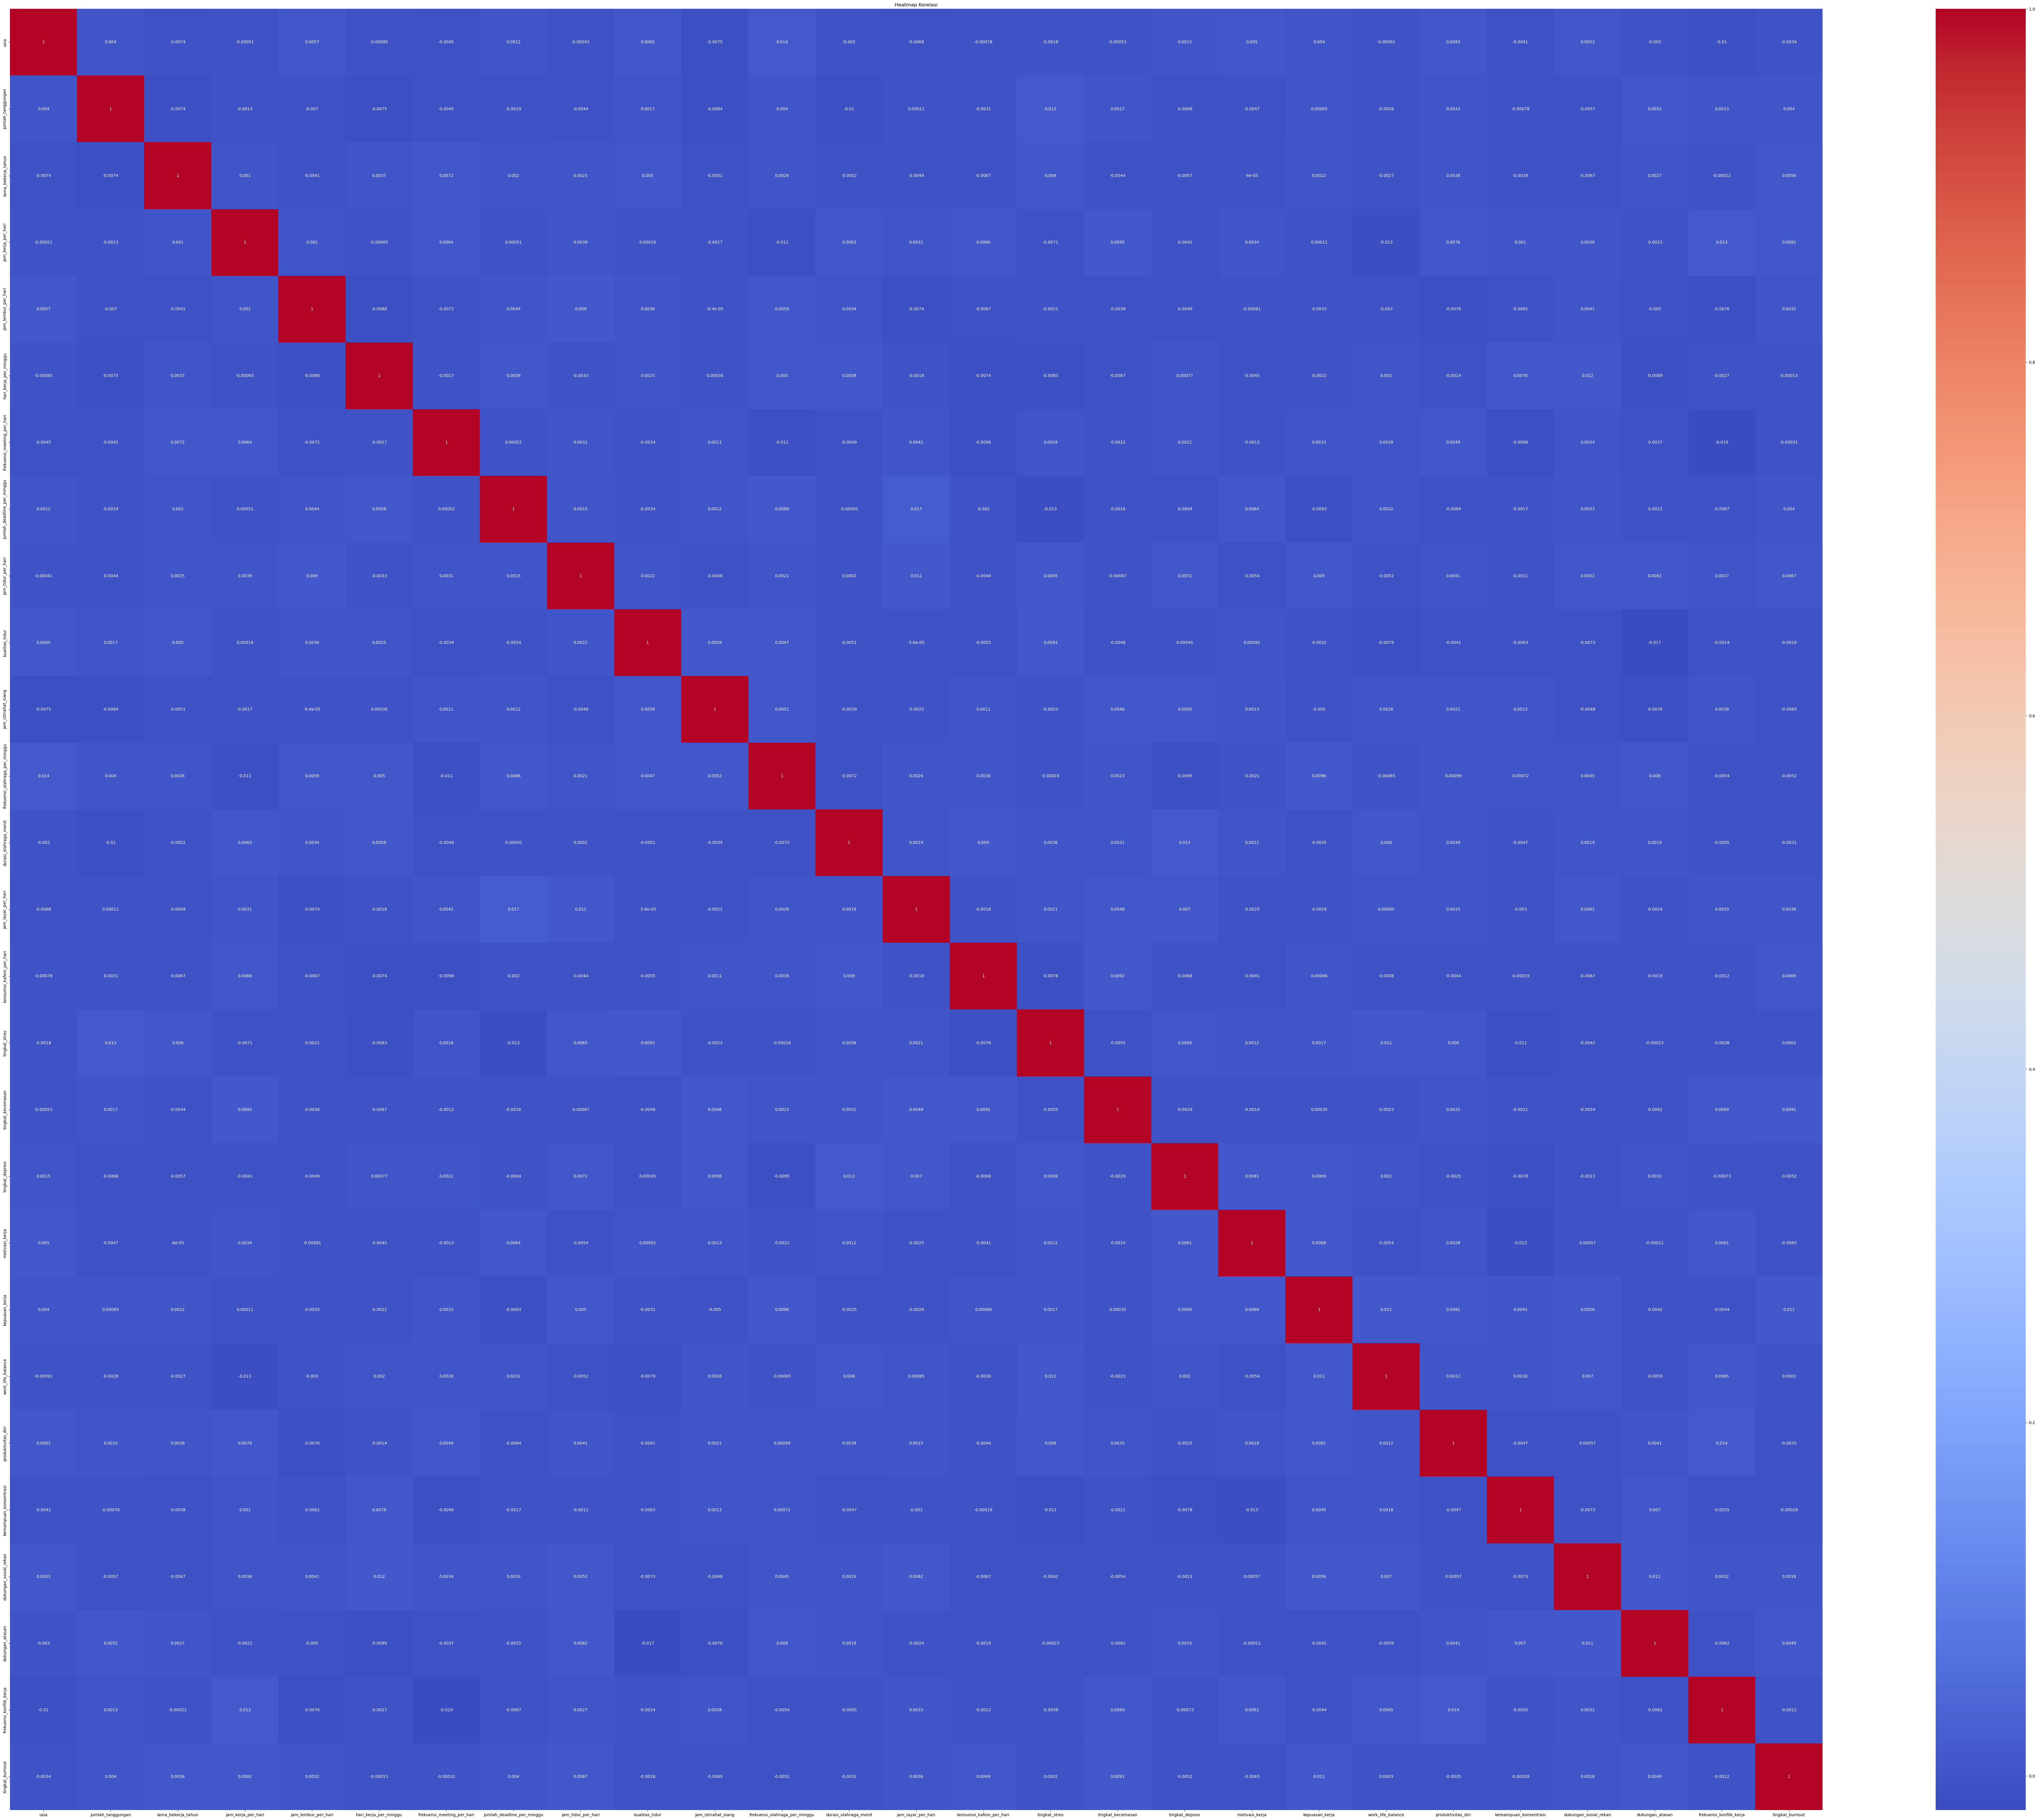